<h2 style="color:blue" align="center">Handwritten digits classification using CNN</h2>

In this notebook we will classify handwritten digits using a simple neural network (ANN) first and than repeat same thing with convolutional neural network. We will see how accuracy improves clickly when you use convolutional neural network.

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [21]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [22]:
X_train.shape

(60000, 28, 28)

In [23]:
X_test.shape

(10000, 28, 28)

In [24]:
X_train[0].shape

(28, 28)

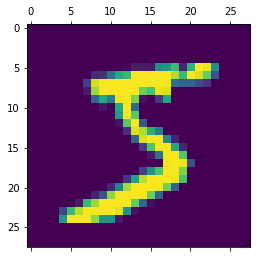

In [25]:
plt.matshow(X_train[0])

In [26]:
y_train[0]

5

In [27]:
X_train = X_train / 255
X_test = X_test / 255

<h3 style='color:purple'>Using ANN for classification</h3>

In [28]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])



In [29]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 100)               78500     
                                                                 
 dense_3 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


In [30]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [31]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2699 - accuracy: 0.9233
Epoch 2/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.1192 - accuracy: 0.9642
Epoch 3/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0833 - accuracy: 0.9750
Epoch 4/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0628 - accuracy: 0.9807
Epoch 5/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0503 - accuracy: 0.9842
Epoch 6/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0396 - accuracy: 0.9880
Epoch 7/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0323 - accuracy: 0.9901
Epoch 8/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0269 - accuracy: 0.9920
Epoch 9/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0220 - accuracy: 0.9934
Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.019

In [32]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.0809 - accuracy: 0.9770


[0.08089637756347656, 0.9769999980926514]

In [42]:
X_train = X_train.reshape(-1,28,28,1)
X_train.shape

(60000, 28, 28, 1)

In [43]:
X_test = X_test.reshape(-1,28,28,1)
X_test.shape

(10000, 28, 28, 1)

In [44]:
from tensorflow.keras.callbacks import Callback, CSVLogger, EarlyStopping, LearningRateScheduler, ModelCheckpoint, ReduceLROnPlateau

<h3 style='color:purple'>Using CNN for classification</h3>

In [45]:
model1 = keras.Sequential([
    
    layers.Conv2D(30,(3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),
 
    #layers.Conv2D(40,(3,3), activation='relu'),
    #layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [37]:
model1.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 26, 26, 30)        300       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 13, 13, 30)       0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 5070)              0         
                                                                 
 dense_4 (Dense)             (None, 100)               507100    
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 508,410
Trainable params: 508,410
Non-trainable params: 0
________________________________________________

In [46]:
model1.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [47]:
filepath="best_weights.hdf5"

In [48]:
checkpoint = ModelCheckpoint(filepath,monitor='val_accuracy',verbose=0, save_best_only=True, mode='max')

In [ ]:
model1.fit(X_train,y_train, epochs=30, batch_size=128,verbose=1, validation_data=(X_test,y_test), callbacks=[checkpoint])

Epoch 1/30
469/469 [==============================] - 27s 57ms/step - loss: 0.2266 - accuracy: 0.9367 - val_loss: 0.0837 - val_accuracy: 0.9751
Epoch 2/30
469/469 [==============================] - 27s 57ms/step - loss: 0.0697 - accuracy: 0.9800 - val_loss: 0.0509 - val_accuracy: 0.9839
Epoch 3/30
469/469 [==============================] - 29s 61ms/step - loss: 0.0476 - accuracy: 0.9857 - val_loss: 0.0457 - val_accuracy: 0.9840
Epoch 4/30
469/469 [==============================] - 27s 58ms/step - loss: 0.0356 - accuracy: 0.9892 - val_loss: 0.0497 - val_accuracy: 0.9837
Epoch 5/30
469/469 [==============================] - 26s 56ms/step - loss: 0.0276 - accuracy: 0.9915 - val_loss: 0.0491 - val_accuracy: 0.9852
Epoch 6/30
469/469 [==============================] - 26s 56ms/step - loss: 0.0199 - accuracy: 0.9943 - val_loss: 0.0448 - val_accuracy: 0.9849
Epoch 7/30
469/469 [==============================] - 26s 57ms/step - loss: 0.0153 - accuracy: 0.9957 - val_loss: 0.0454 - val_accuracy:

In [ ]:
model.load_weights("best_weights.hdf5")

In [ ]:
model.evaluate(X_test,y_test)